### **Week 5 Deliverable** - Spencer Lockwood

# Step 1

For this step, I downloaded the reference genome for chromosome 10 (chr10) from the genome browser to use as a reference for read alignment.

# Step 2

I aligned both Illumina (short reads) and PacBio (long reads) sequencing data to the reference genome. minimap2 was used for alignment, samtools was used to convert SAM to BAM, sort, and index the BAM files. My command line inputs are as follows.


\#Install samtools

brew install samtools


\#Align Illumina reads (short reads)*

./minimap2 -ax sr ../fall25-csc-bioinf/week5/data/chr10.mmi ../fall25-csc-bioinf/week5/data/illumina.fq | samtools view -bS - | samtools sort -o ../fall25-csc-bioinf/week5/data/illumina.sorted.bam


\#Index the sorted Illumina BAM

samtools index ../fall25-csc-bioinf/week5/data/illumina.sorted.bam


\#Align PacBio reads (long reads)

./minimap2 -ax map-pb ../fall25-csc-bioinf/week5/data/chr10.mmi ../fall25-csc-bioinf/week5/data/pacbio.fq | samtools view -bS - | samtools sort -o ../fall25-csc-bioinf/week5/data/pacbio.sorted.bam


\#Index the sorted PacBio BAM

samtools index ../fall25-csc-bioinf/week5/data/pacbio.sorted.bam

# Step 3

I called variants for both Illumina and PacBio datasets using bcftools. This generates VCF files containing the variant positions and alleles for each sequencing technology. My command line inputs are as follows.

\#Install bcftools

brew install bcftools

\#Call variants from Illumina BAM

bcftools mpileup -f ../fall25-csc-bioinf/week5/data/chr10.fa ../fall25-csc-bioinf/week5/data/illumina.sorted.bam -Ou | bcftools call -mv -Ov -o ../fall25-csc-bioinf/week5/data/illumina.vcf

\#Call variants from PacBio BAM

bcftools mpileup -f ../fall25-csc-bioinf/week5/data/chr10.fa ../fall25-csc-bioinf/week5/data/pacbio.sorted.bam -Ou | bcftools call -mv -Ov -o ../fall25-csc-bioinf/week5/data/pacbio.vcf

# Step 4

I used HapCUT2 to extract read fragments and phase variants from the VCFs. This produces phased VCF files that indicate which variants are on the same haplotype.

\#Extract read fragments for Illumina

build/extractHAIRS --bam ../fall25-csc-bioinf/week5/data/illumina.sorted.bam --VCF ../fall25-csc-bioinf/week5/data/illumina.vcf --out ../fall25-csc-bioinf/week5/data/illumina.fragments

\#Extract read fragments for PacBio

build/extractHAIRS --bam ../fall25-csc-bioinf/week5/data/pacbio.sorted.bam --VCF ../fall25-csc-bioinf/week5/data/pacbio.vcf --out ../fall25-csc-bioinf/week5/data/pacbio.fragments

\#Phase variants using HapCUT2 for Illumina

build/HAPCUT2 --fragments ../fall25-csc-bioinf/week5/data/illumina.fragments --VCF ../fall25-csc-bioinf/week5/data/illumina.vcf --output ../fall25-csc-bioinf/week5/data/illumina.phased.vcf

\#Phase variants using HapCUT2 for PacBio

build/HAPCUT2 --fragments ../fall25-csc-bioinf/week5/data/pacbio.fragments --VCF ../fall25-csc-bioinf/week5/data/pacbio.vcf --output ../fall25-csc-bioinf/week5/data/pacbio.phased.vcf


# Step 5

I chose three uniqiue variants of each illumina and pacbio. They are as follows.

Illumina:
- chr10   94240405        G       A
- chr10   94241293        G       A
- chr10   94252108        T       G

Pacbio:
- chr10   94167078        G       A
- chr10   94496543        G       A
- chr10   94497132        G       A

### PacBio Variants
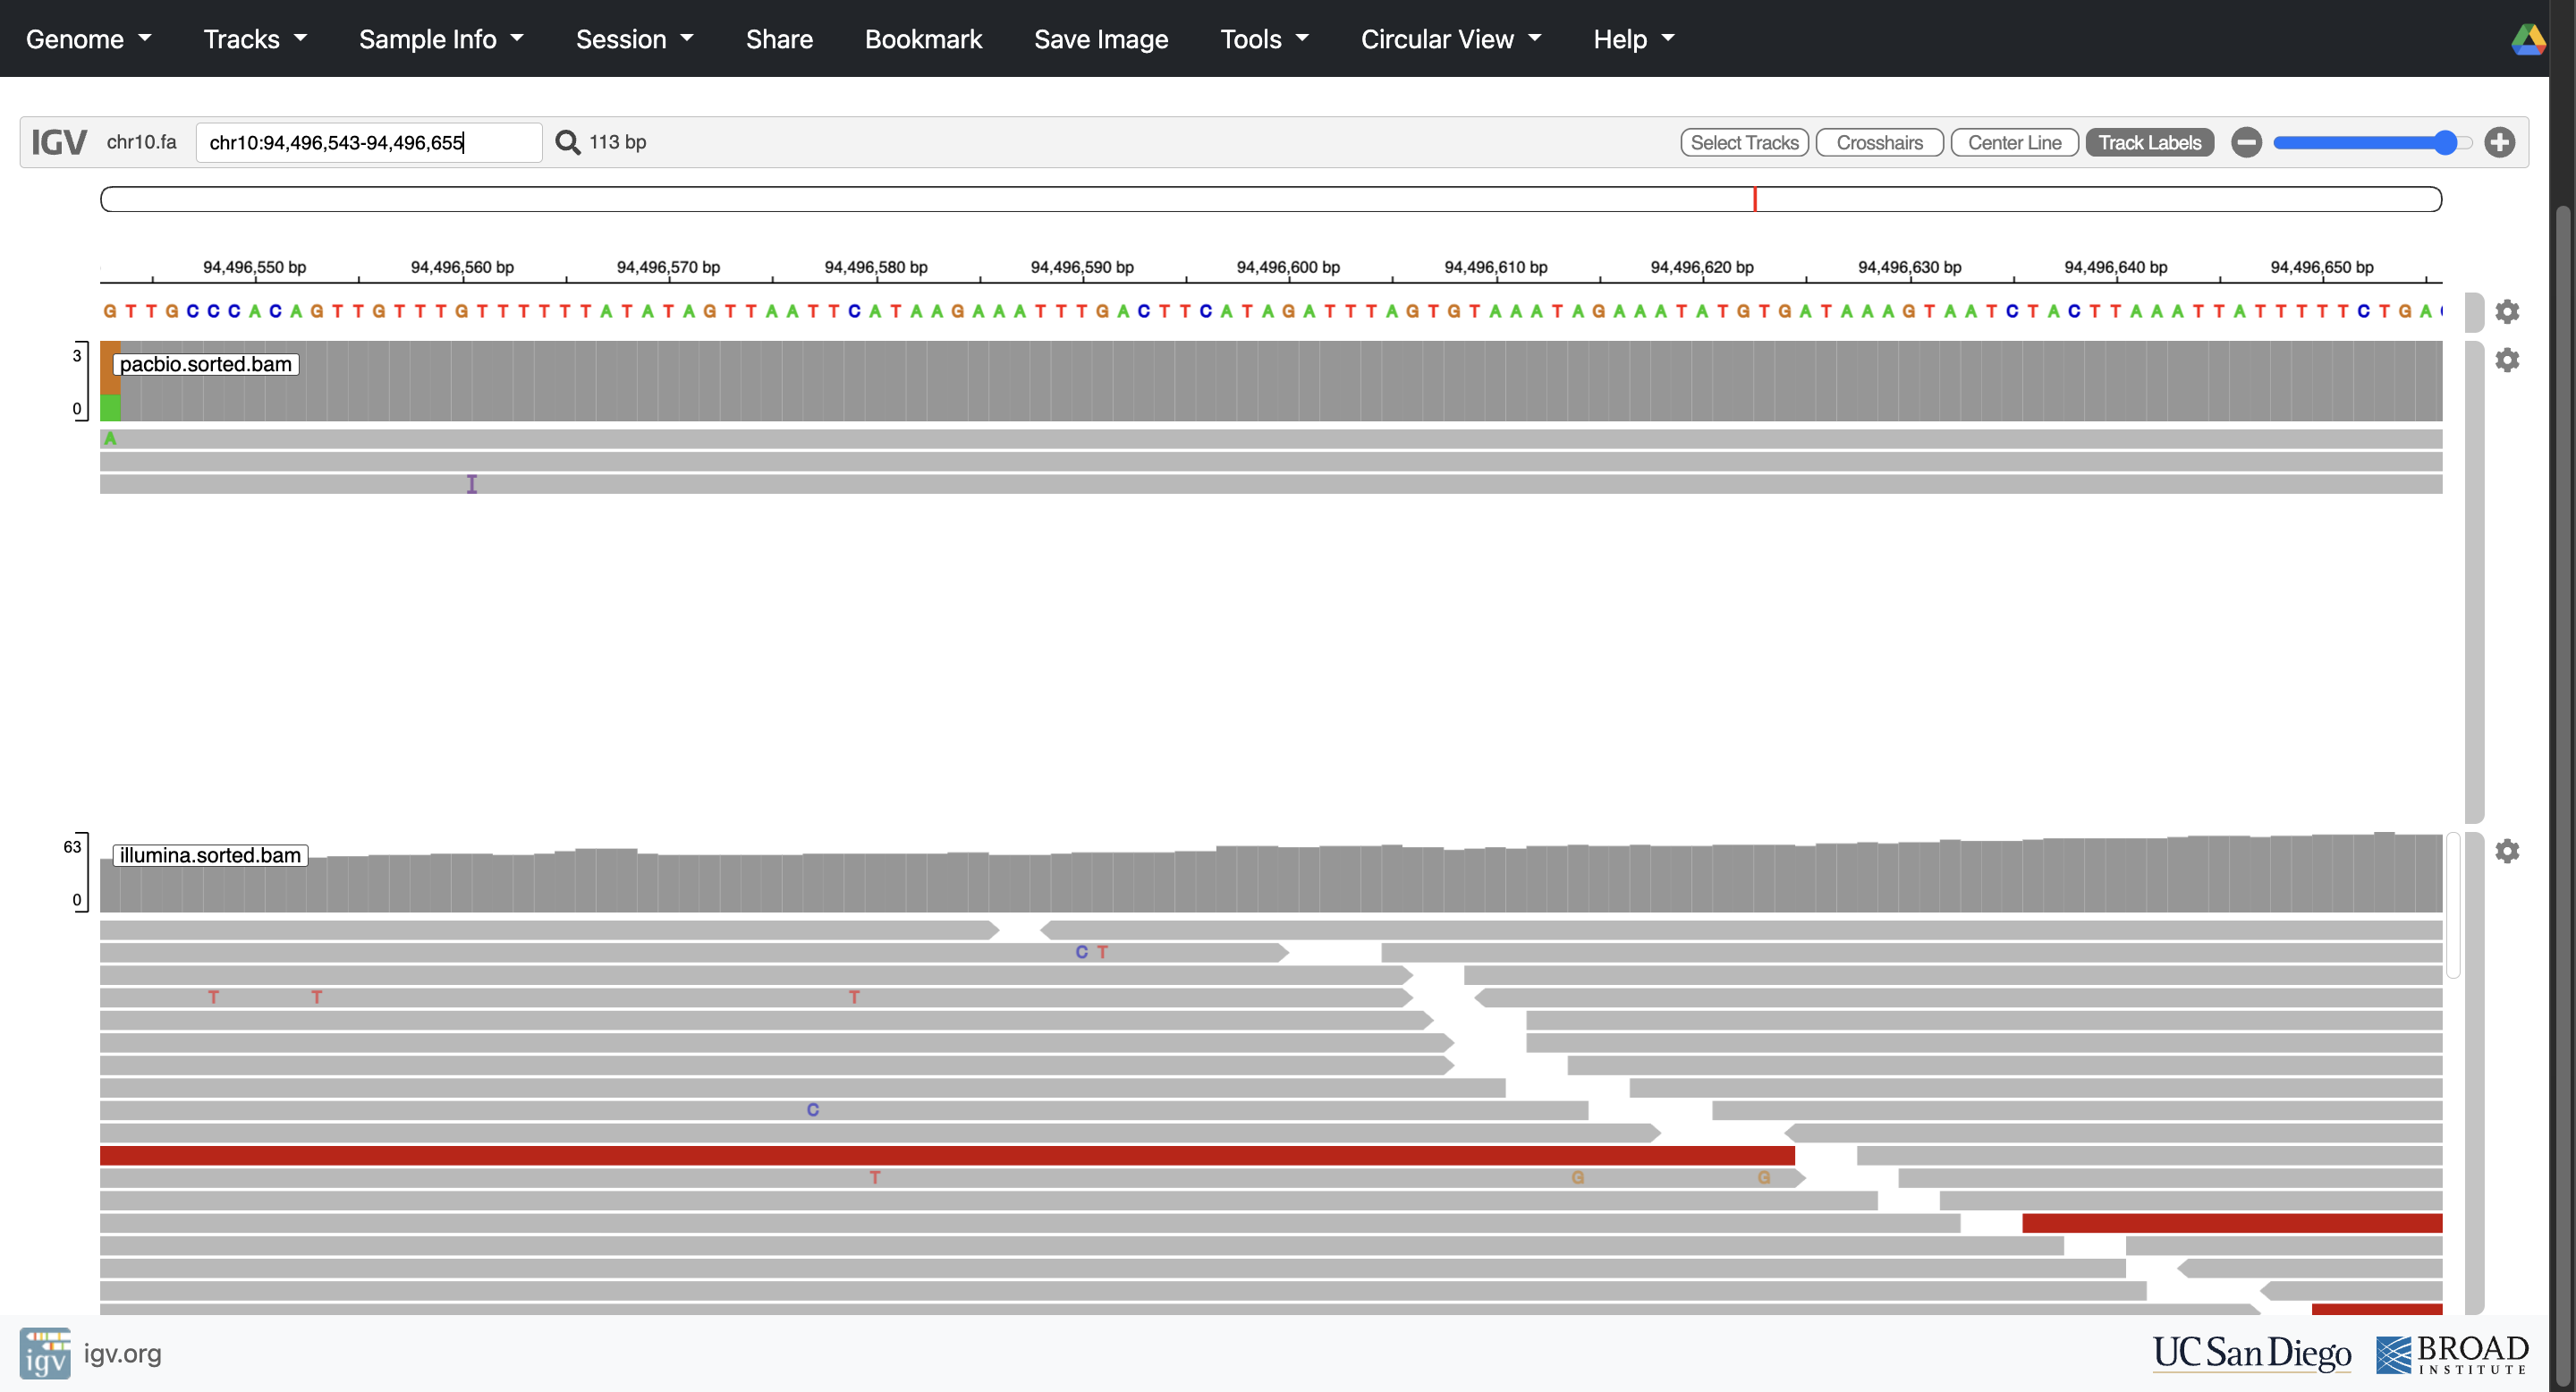
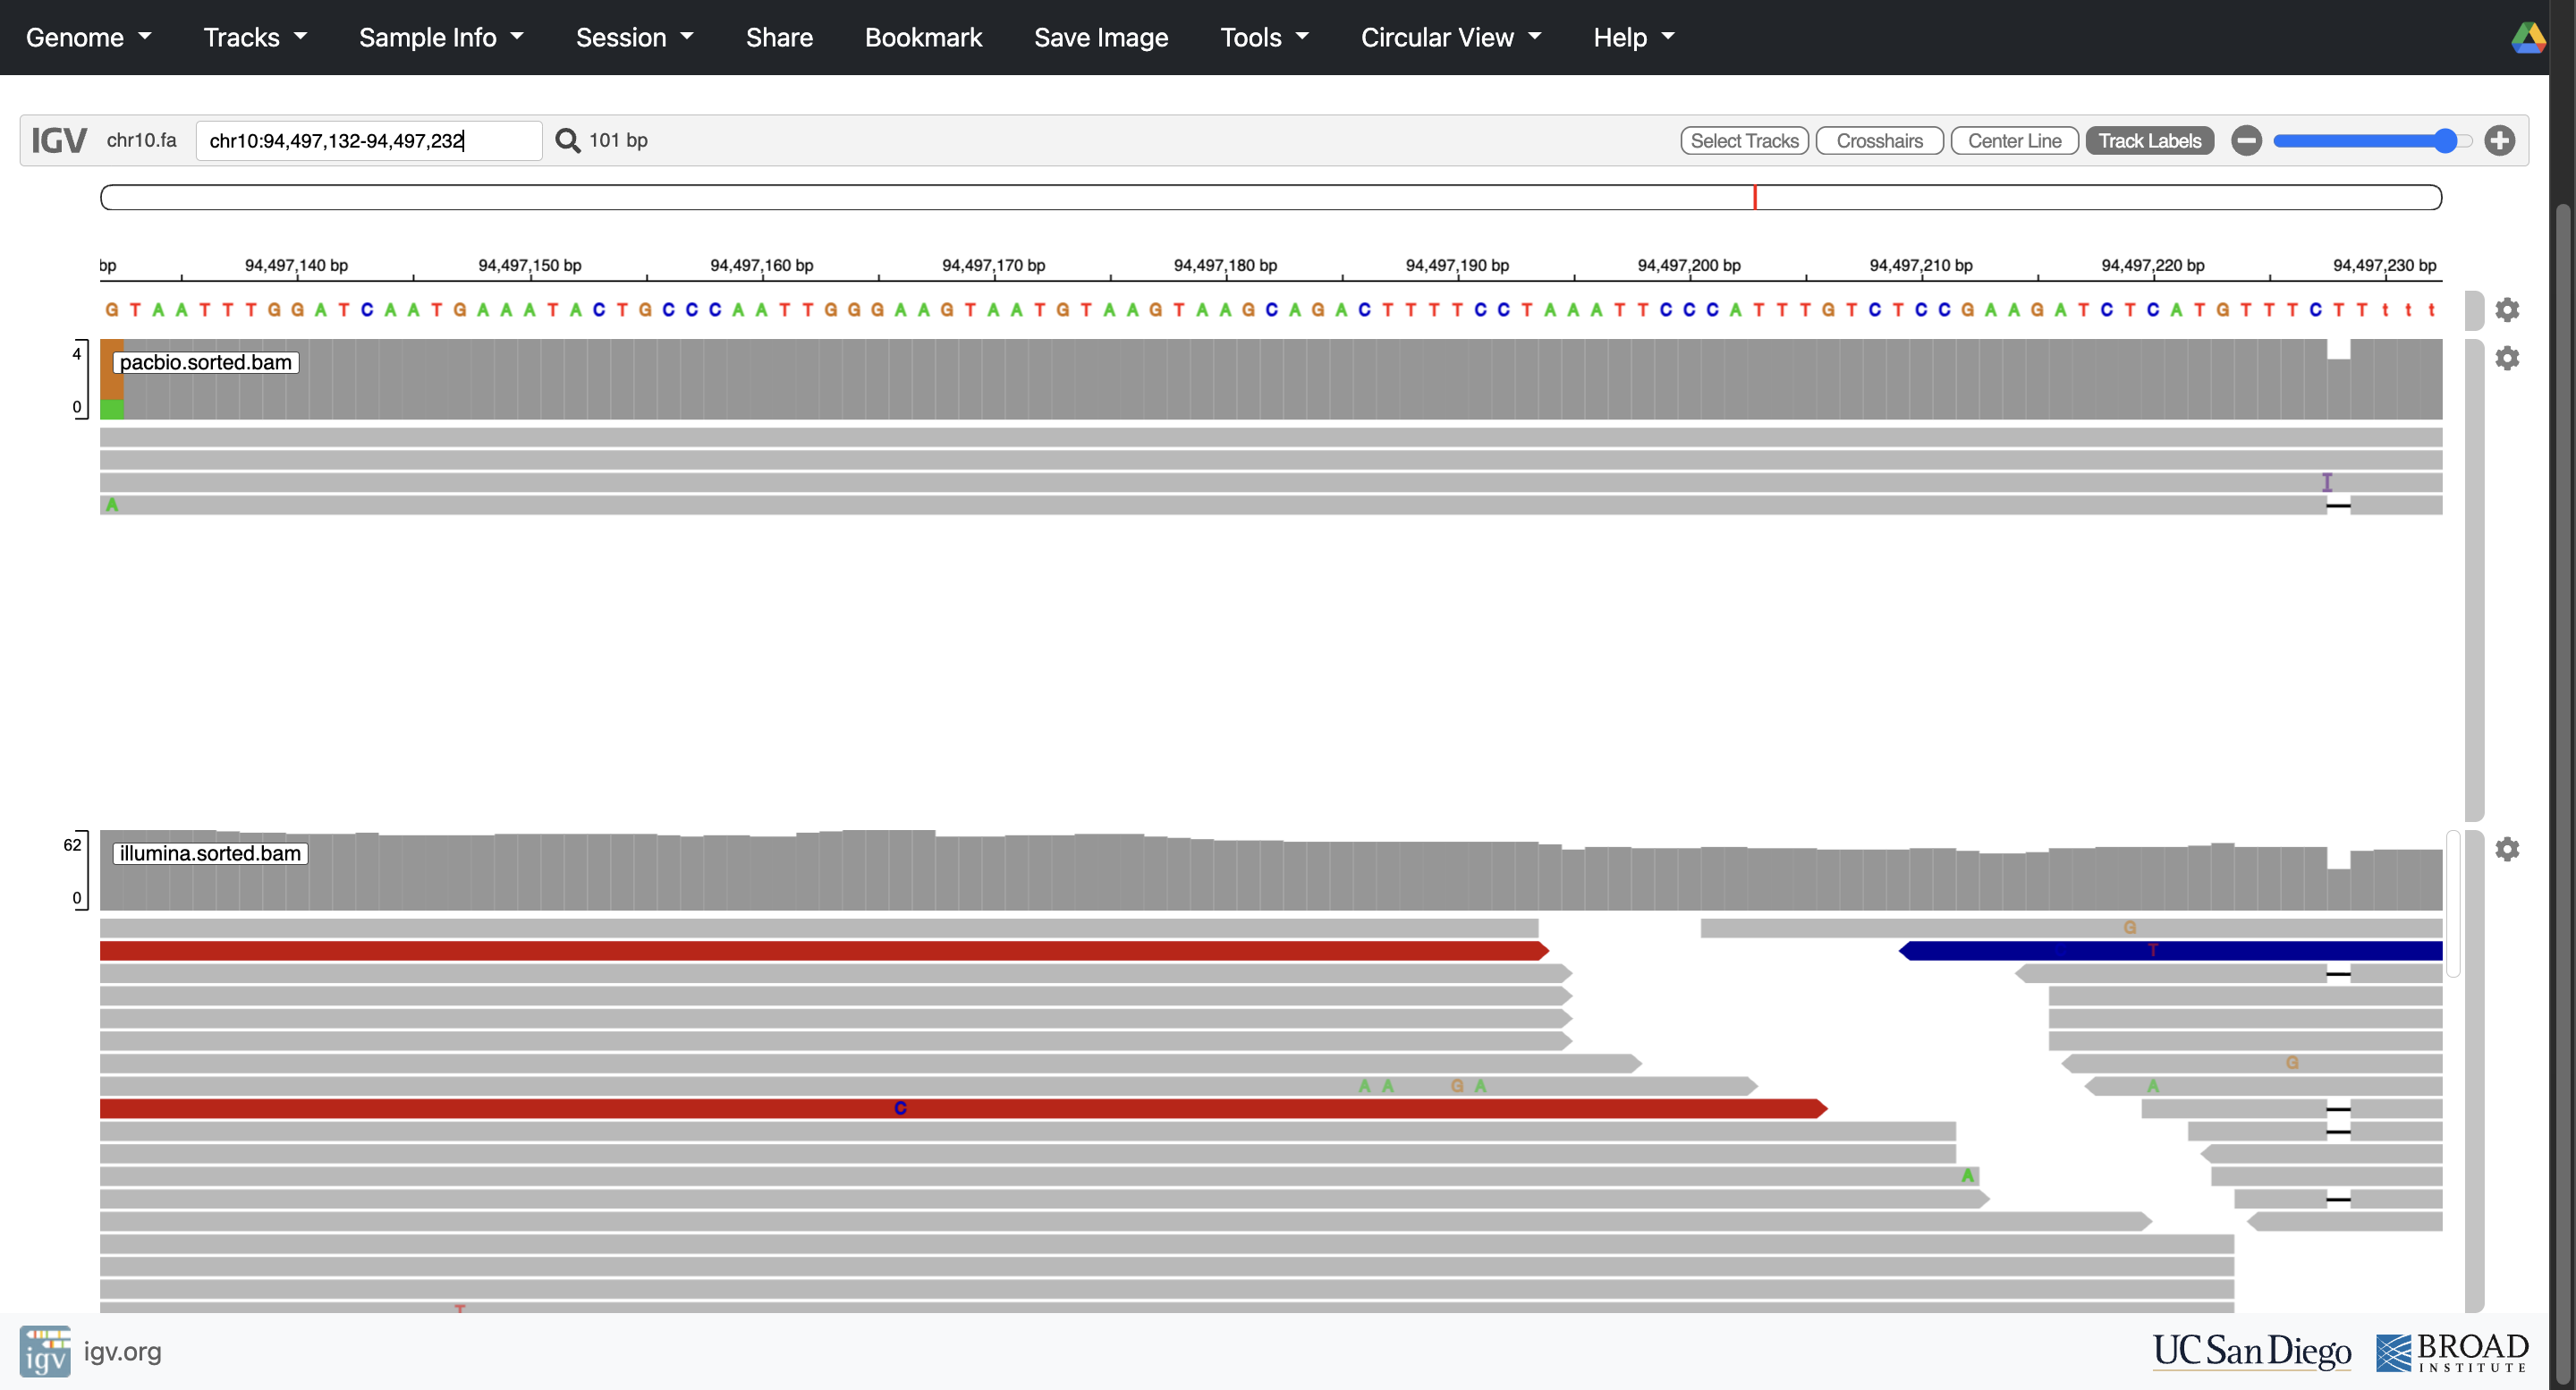
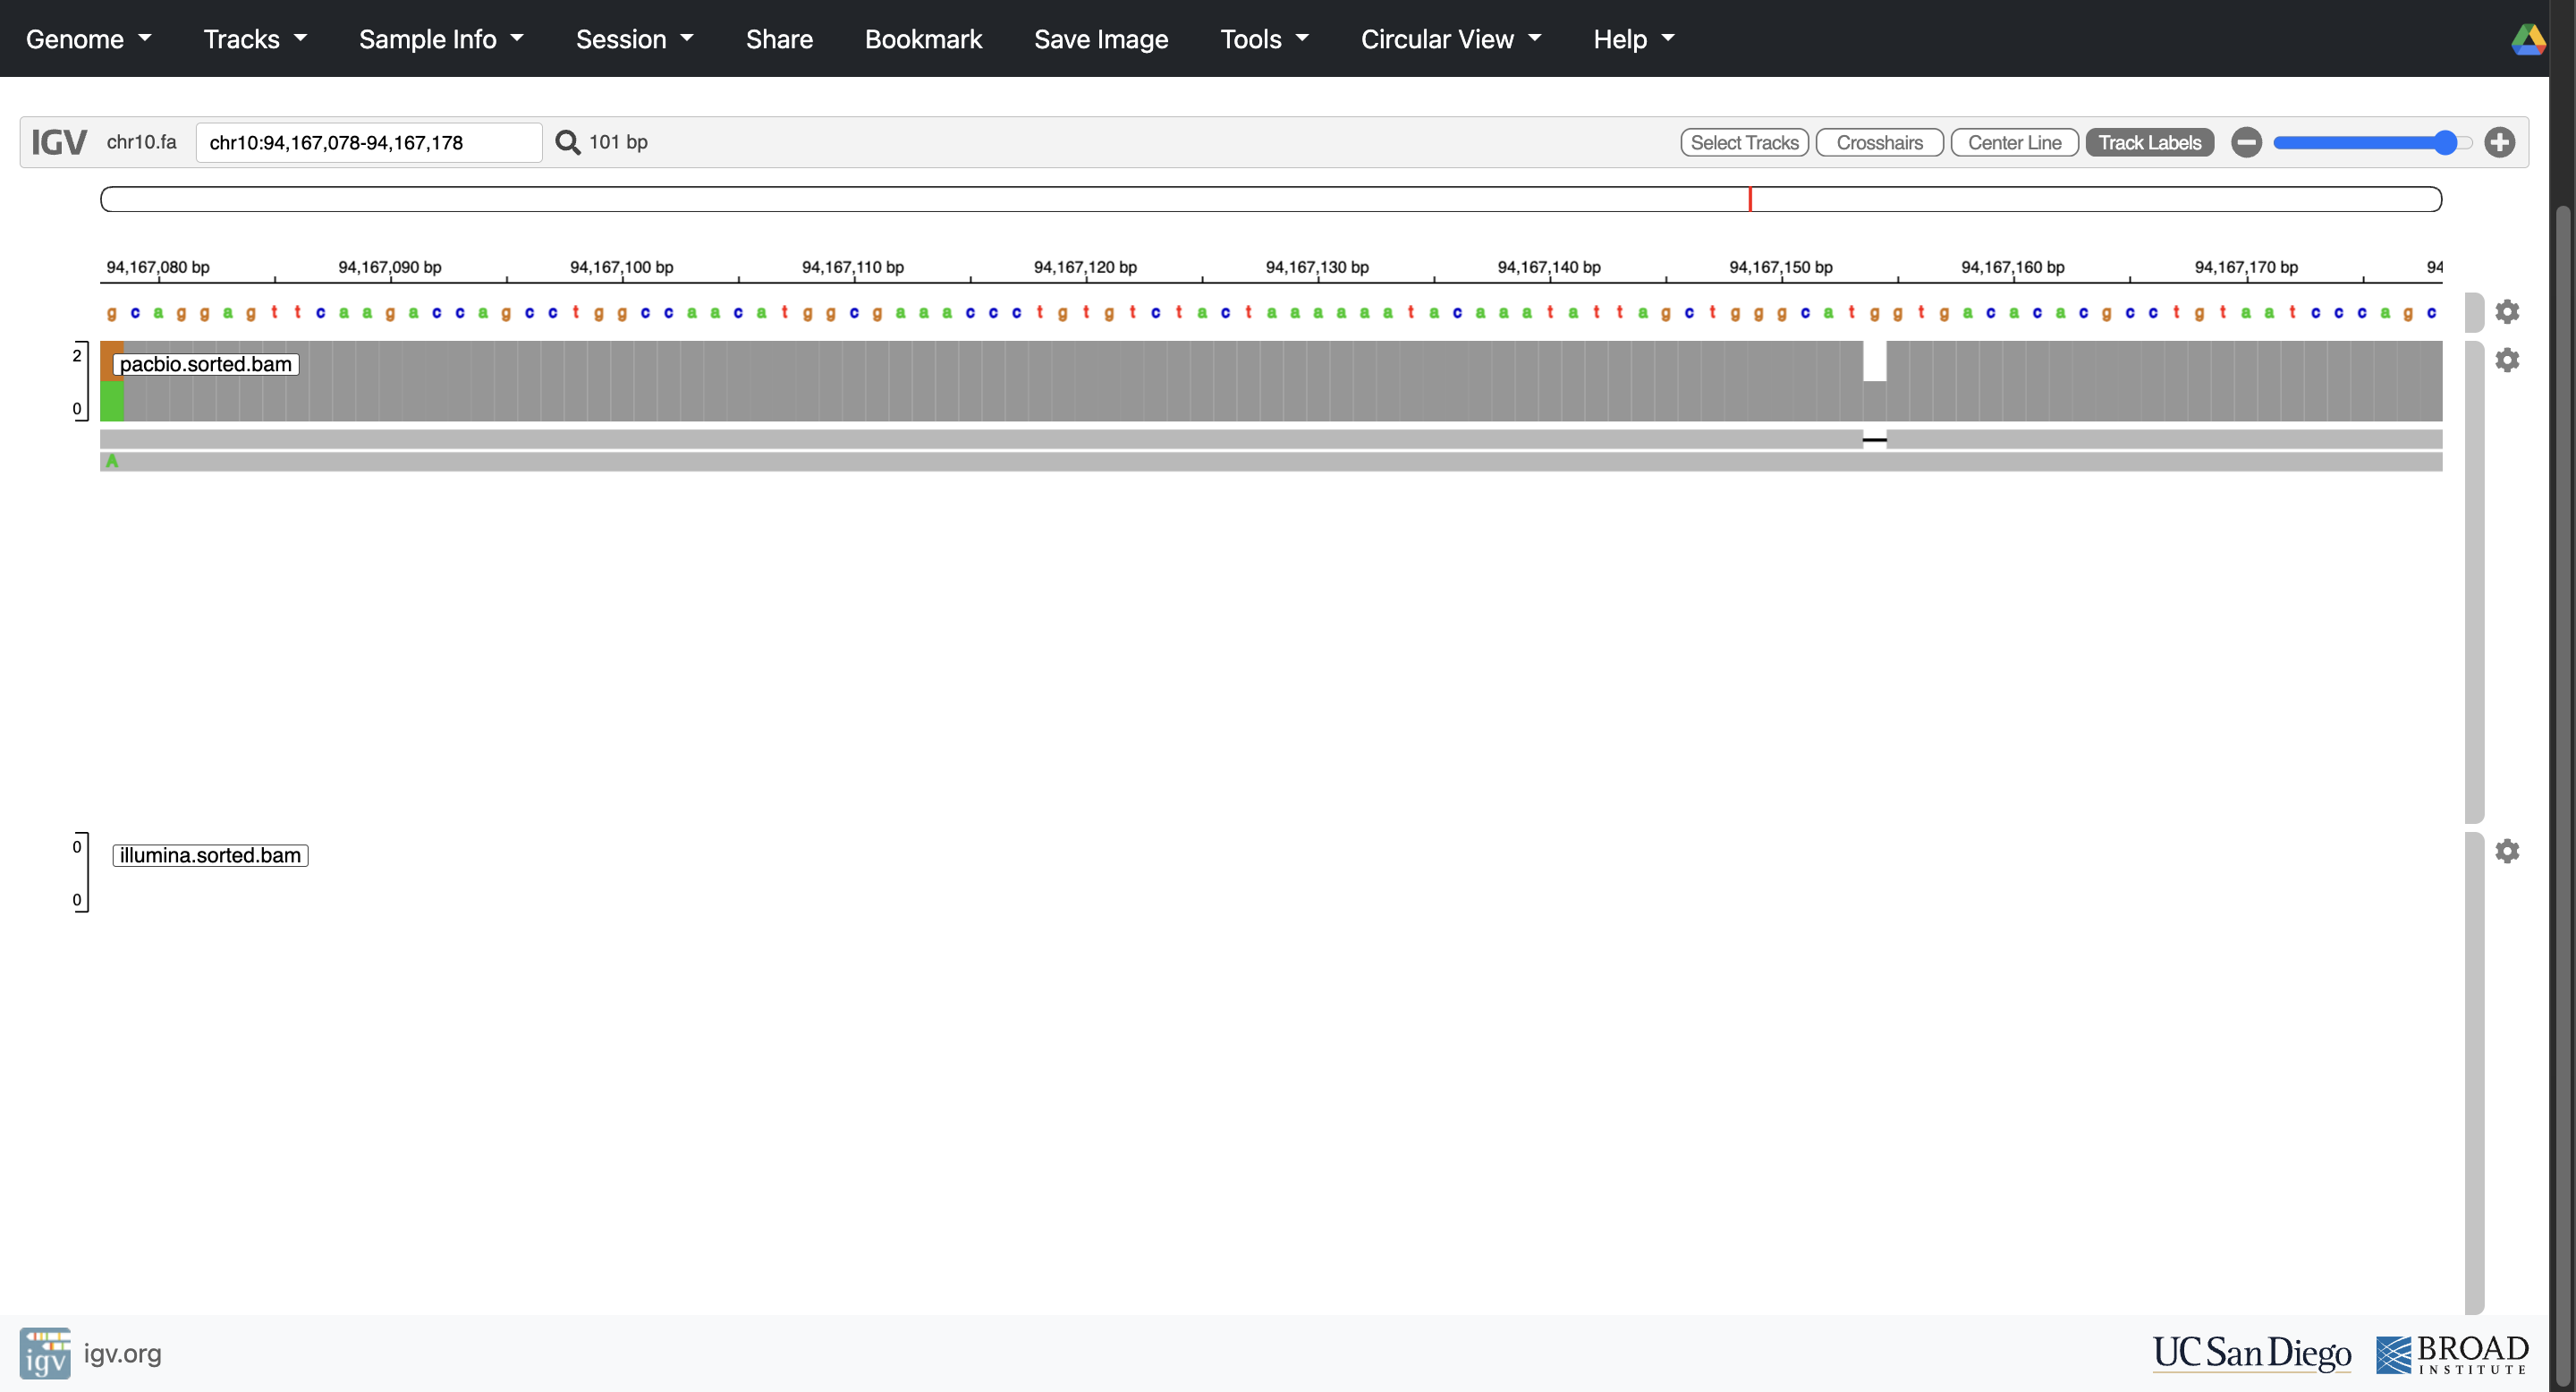

### Pacbio Variants
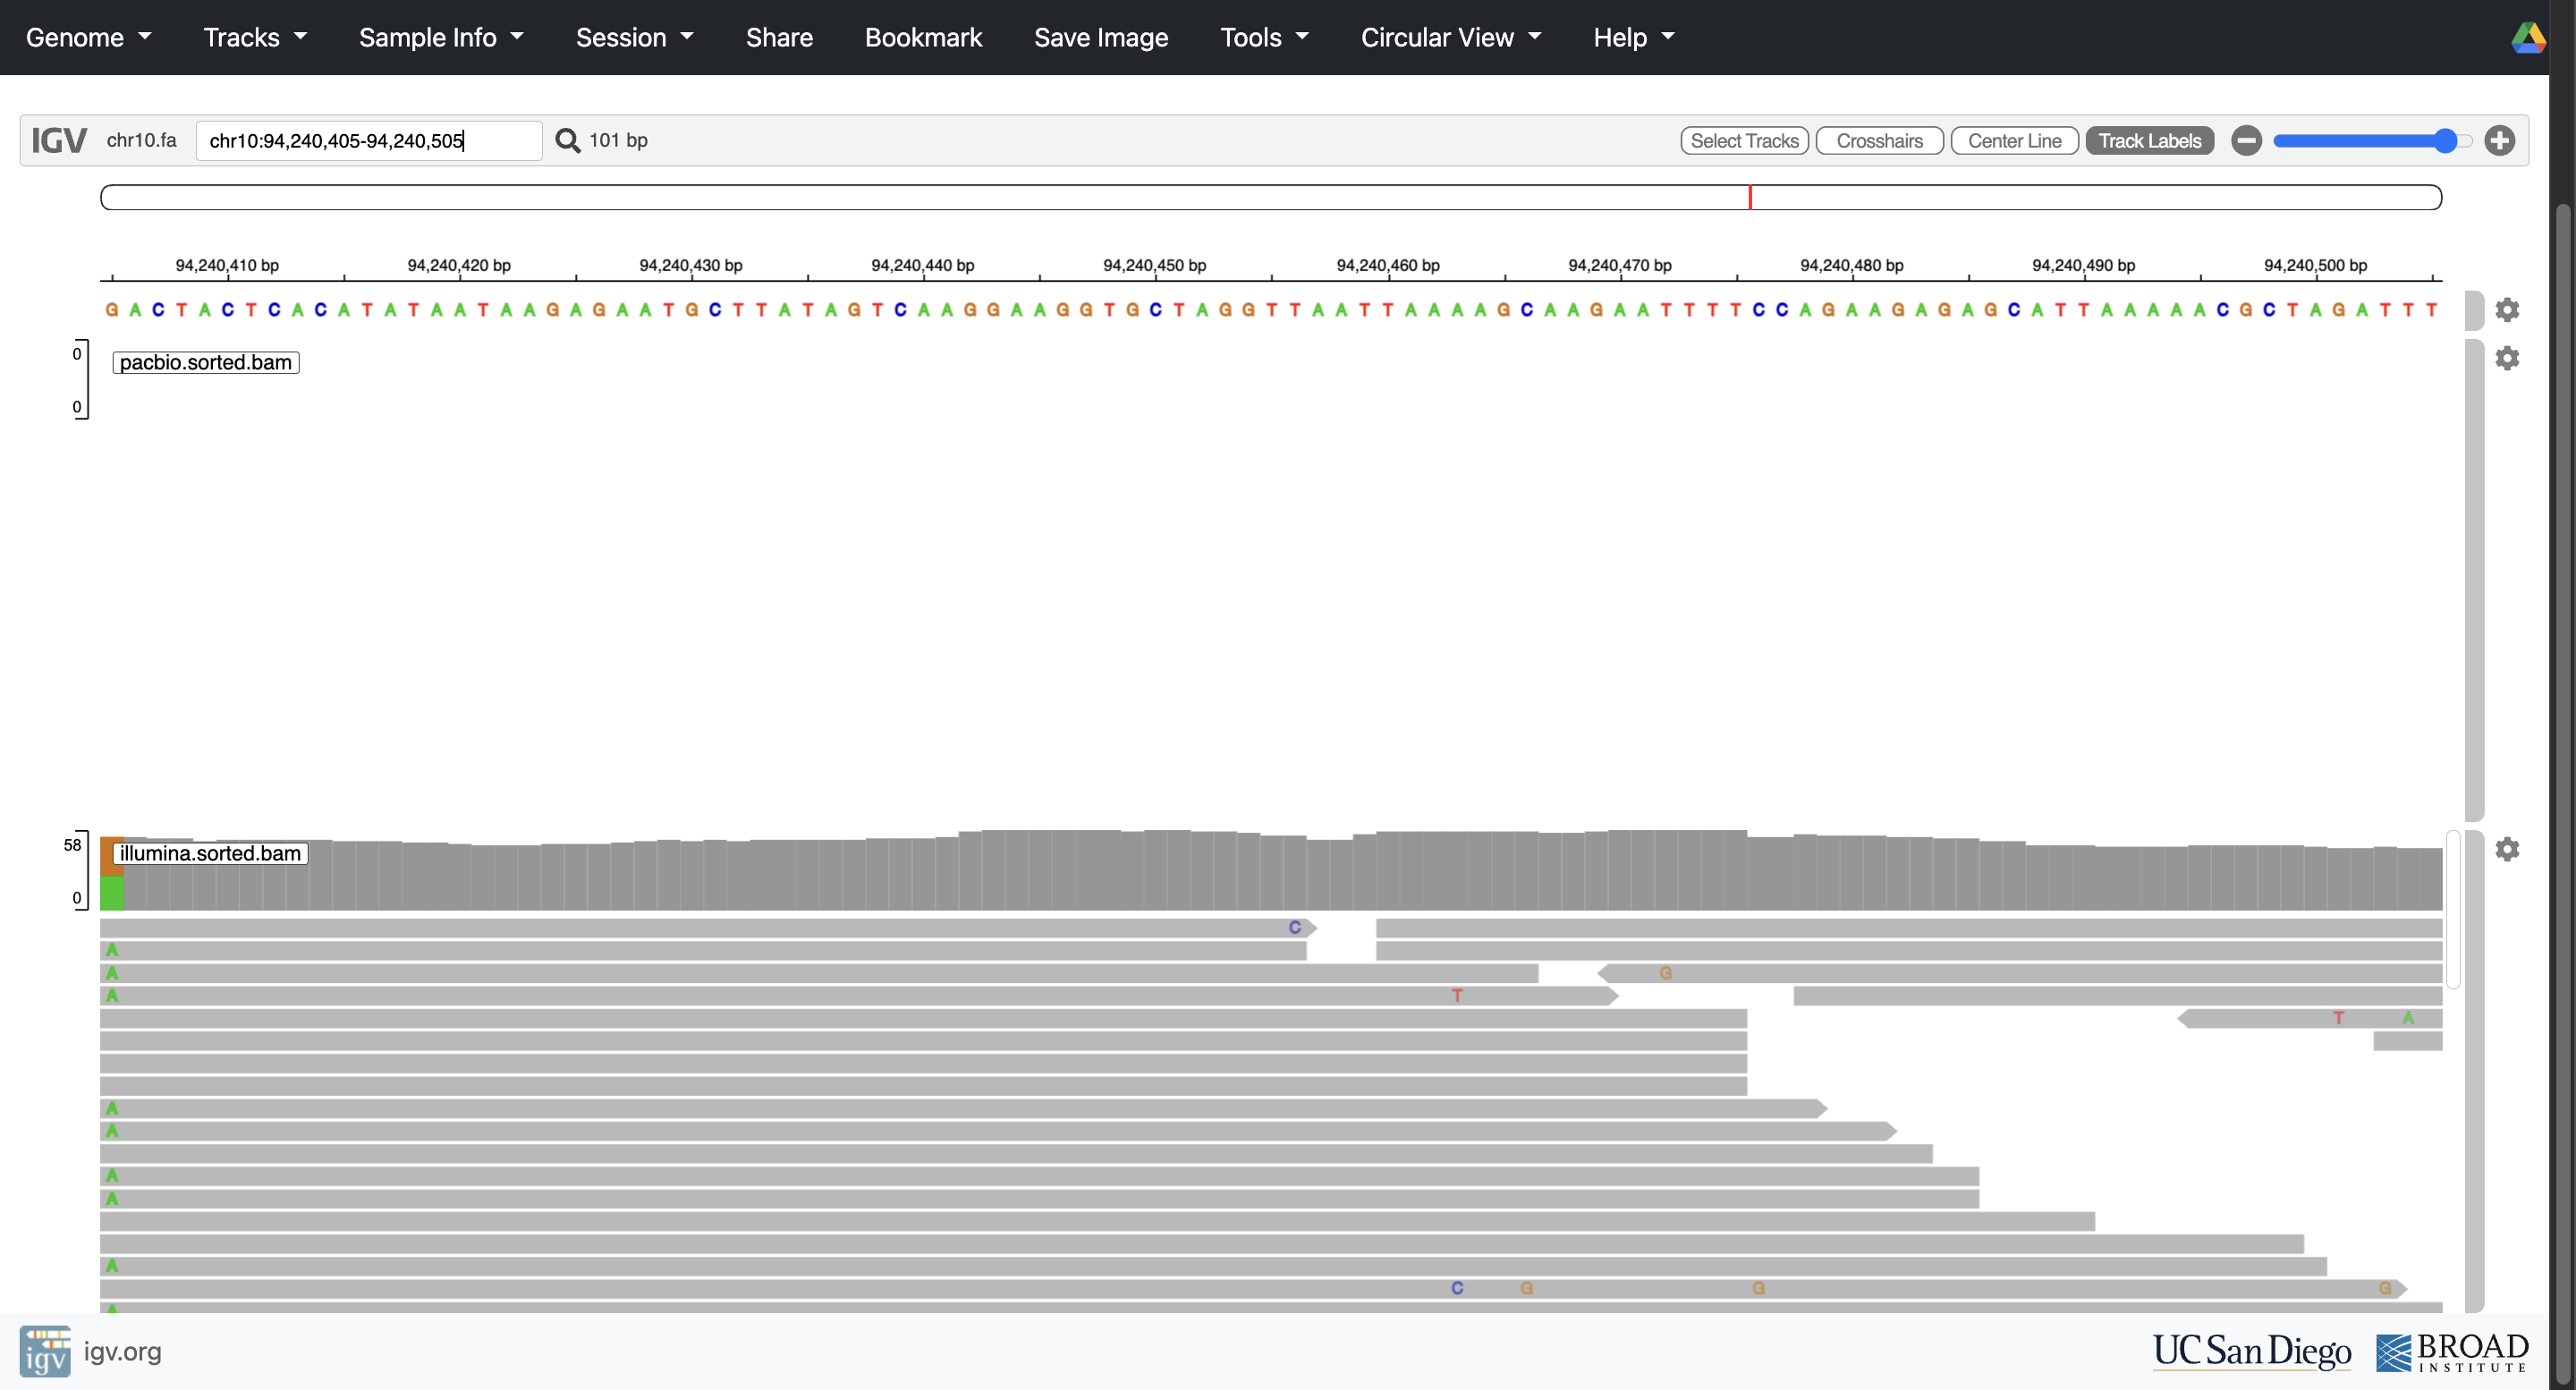
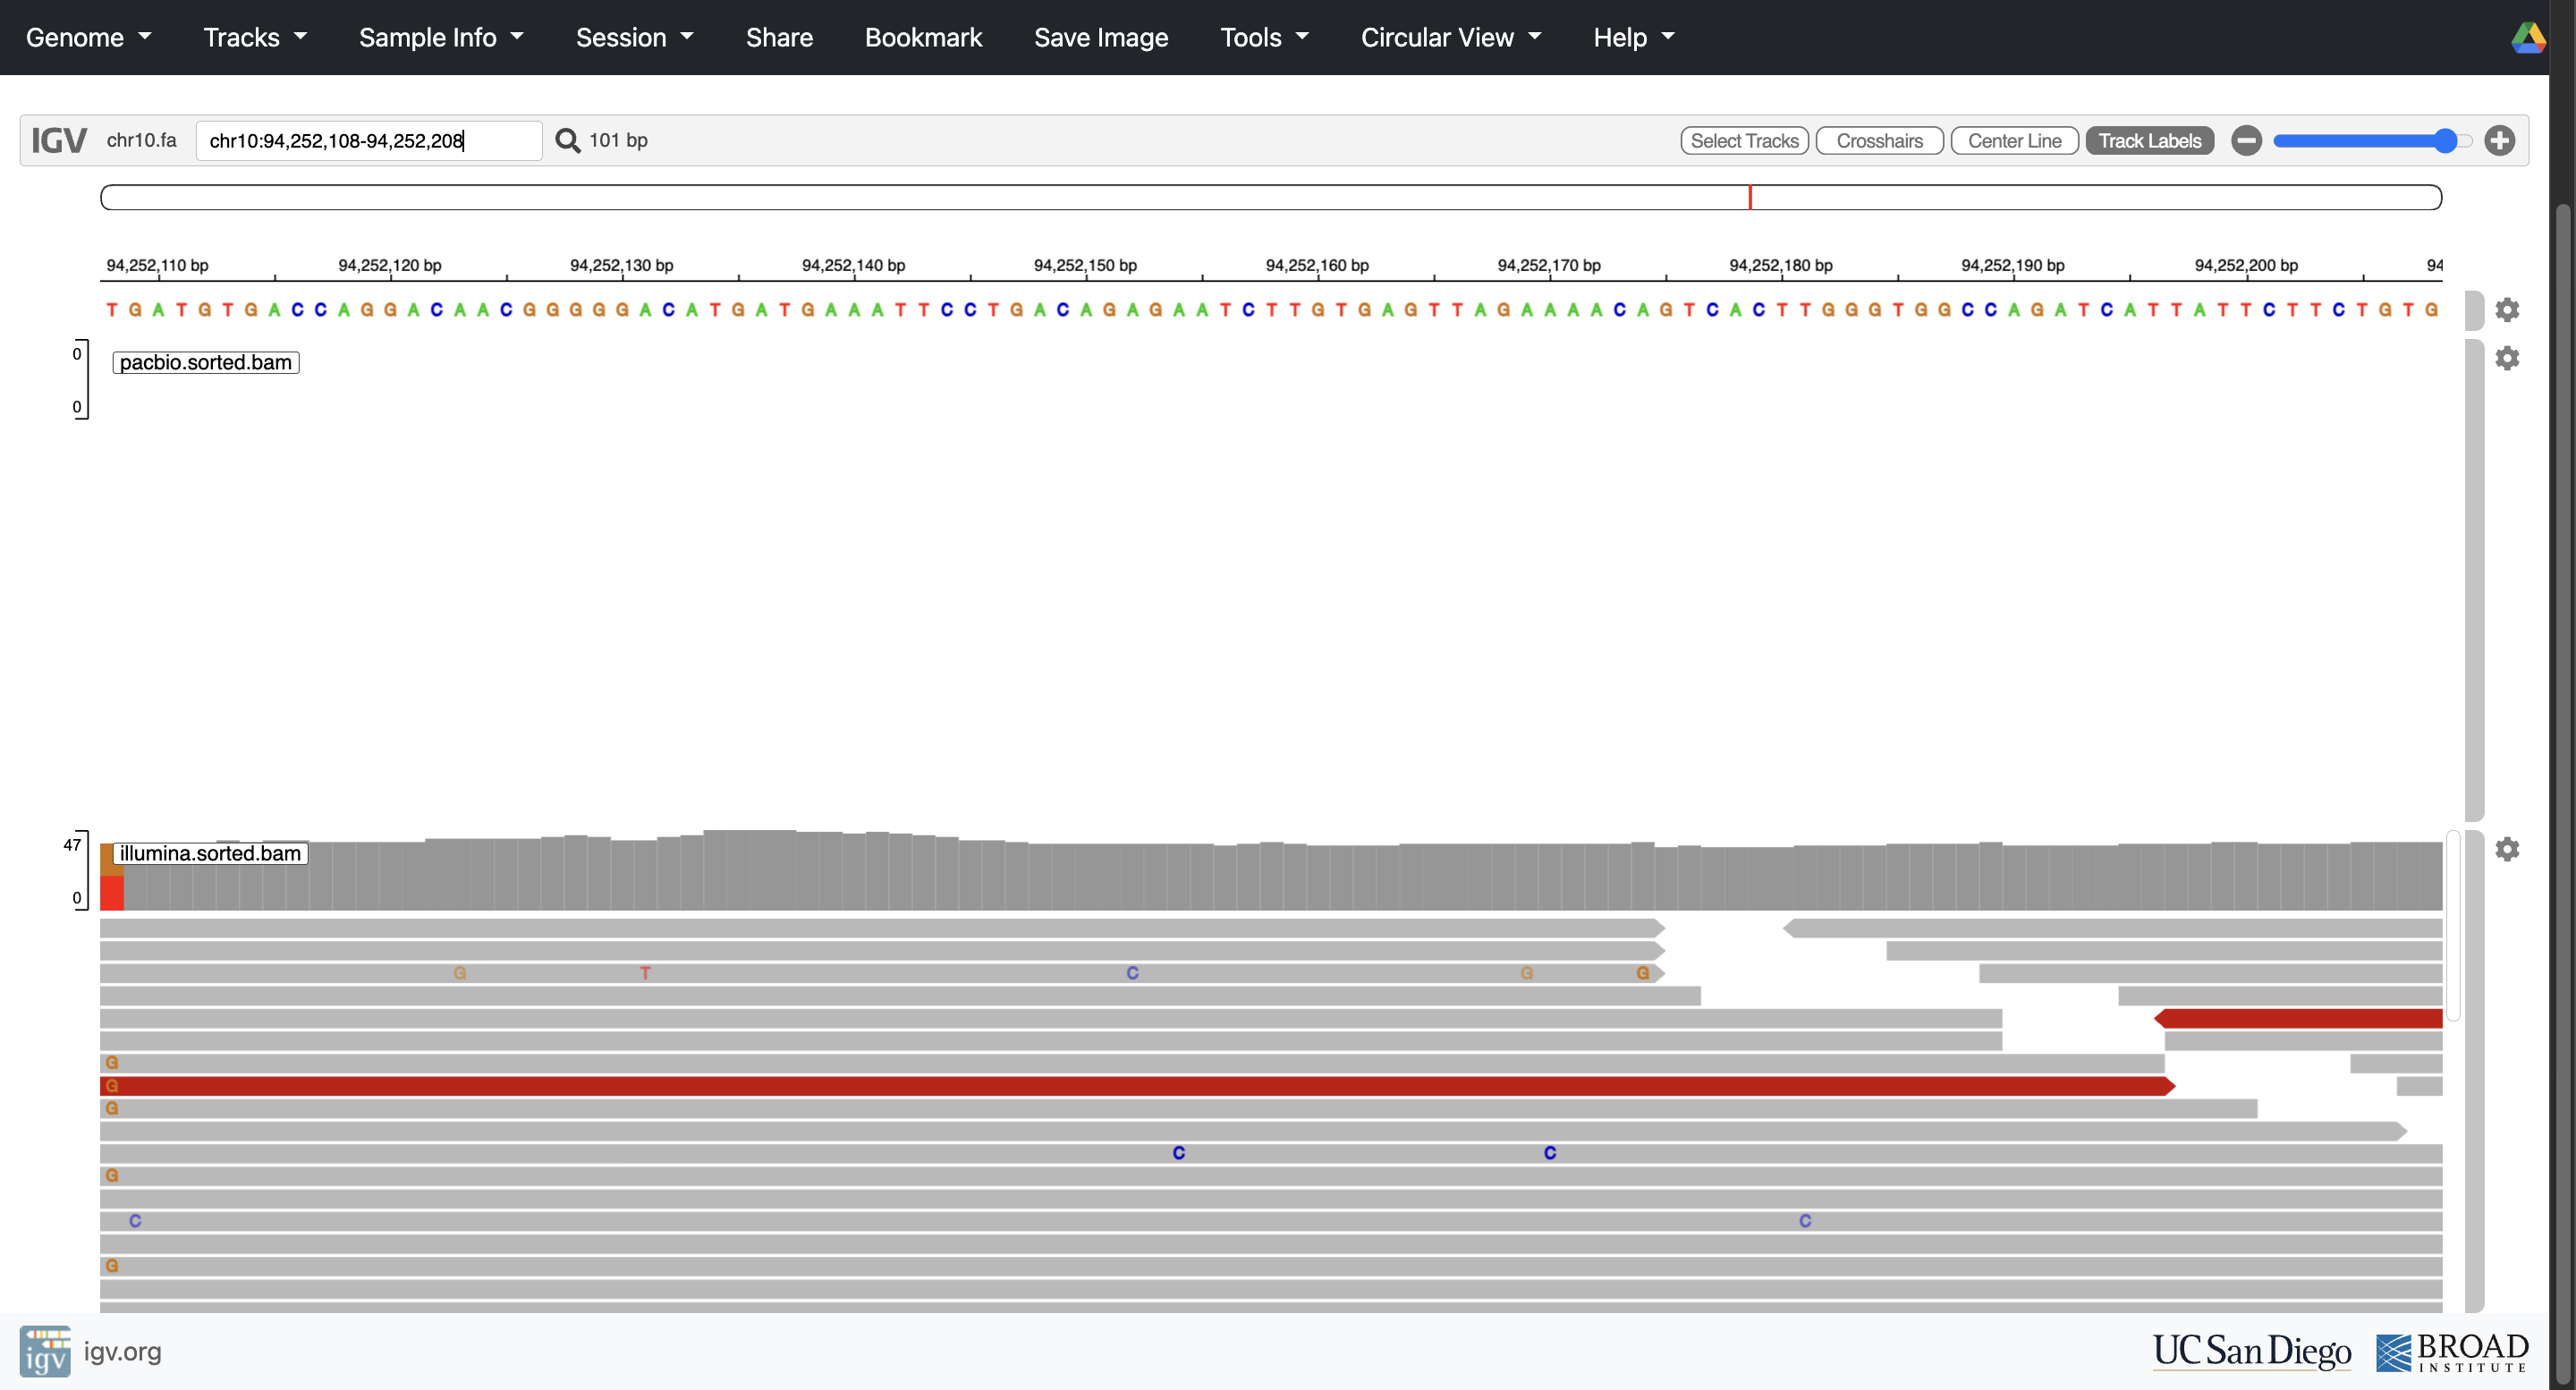
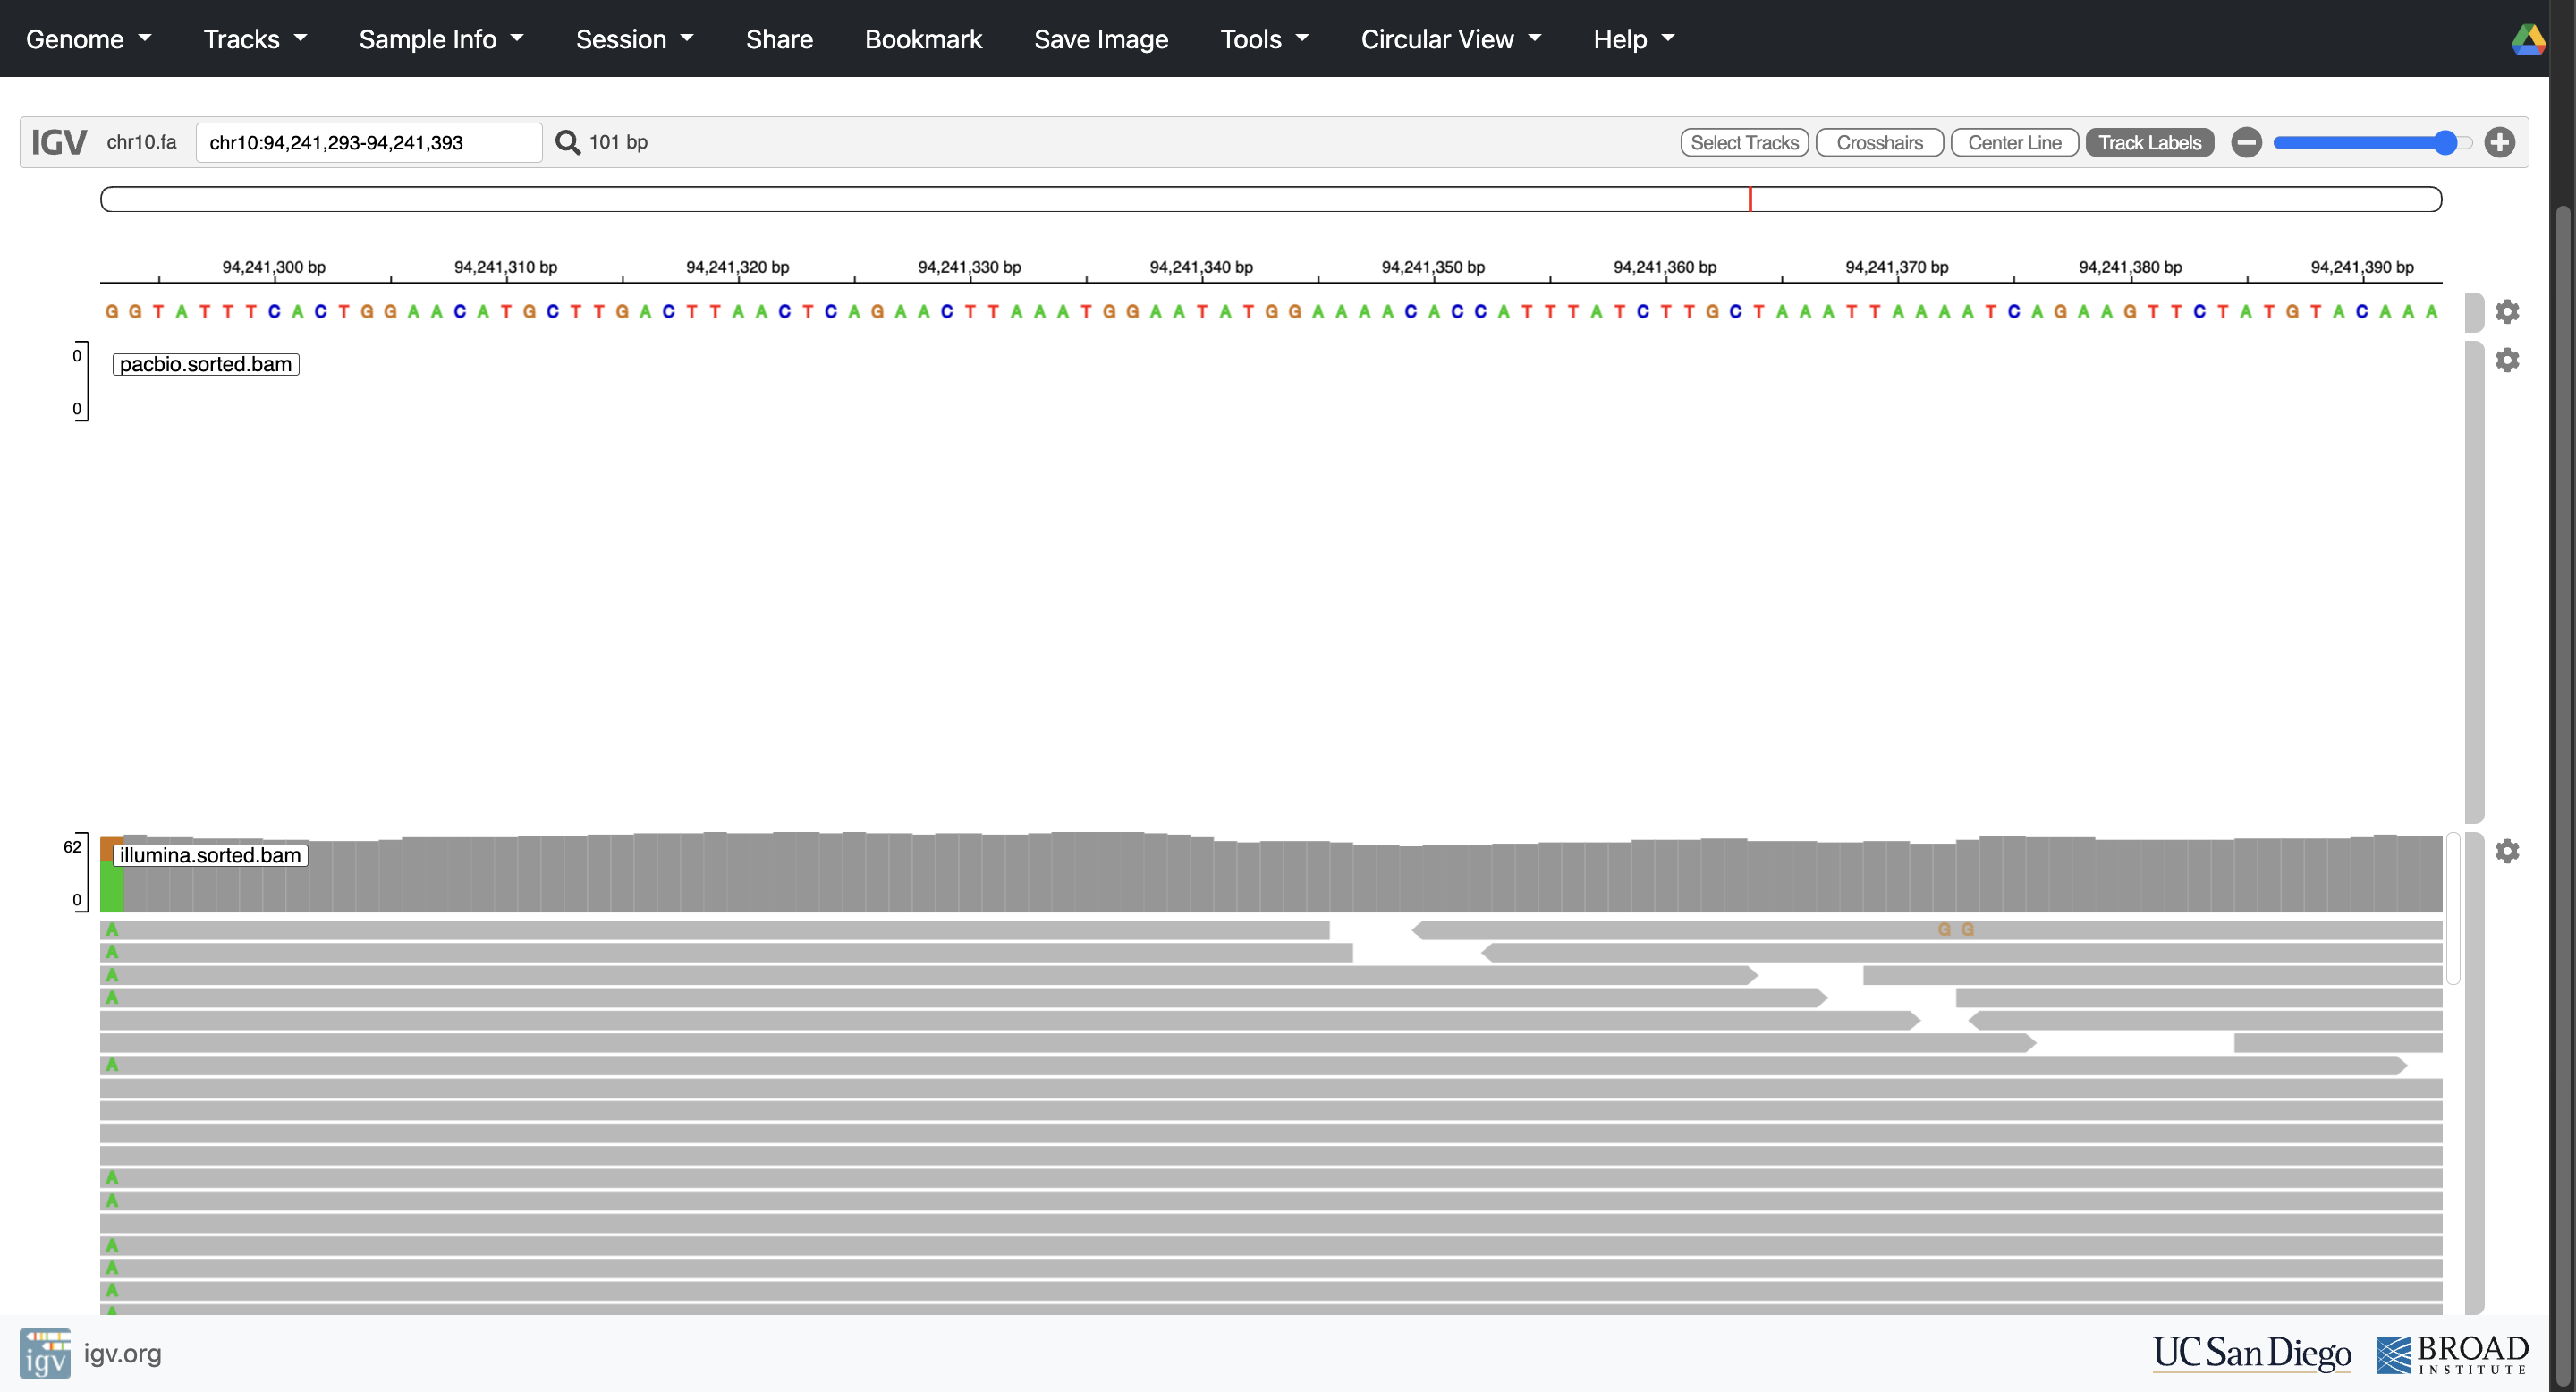

### *What I found:*

### Shared variants: 169 variants are in both Illumina and PacBio data.

Unique variants:
- 698 only in Illumina
- 169 only in PacBio

698 + 169 - 148 = 719 non-shared variants


### Looking at the unique variants in IGV:

Illumina-unique: None of these variants had any PacBio reads at the same positions. This means these variants are real, but only Illumina detected them, probably because of its short-read coverage.

PacBio-unique: Two of the three variants I checked had some Illumina reads at the same position, and one had none. This suggests that some PacBio-unique variants are real but maybe too low coverage for Illumina, and some could be long-read specific.

## Takeaways:
- Most differences are because of the type of sequencing or coverage, not errors.
- Illumina picks up some short-read variants that PacBio misses.
- PacBio finds some variants that Illumina doesn’t see.

Overall, the unique variants mostly seem like real variants, not sequencing mistakes.

# Step 6

Using the phased VCFs from both Illumina and PacBio sequencing, I checked the variants that define known CYP2C19 star alleles (from PharmVar). For both datasets, only the wild-type allele, CYP2C19*1, was detected. This indicates that in our sample, there are no known loss-of-function or gain-of-function variants in CYP2C19, and both haplotypes correspond to the reference sequence. My code for this is below.

In [3]:
import pandas as pd

# Step 1: Load phased VCF into a DataFrame
def load_phased_vcf(vcf_file):
    variants = []
    with open(vcf_file) as f:
        for line in f:
            if line.startswith("#") or line.startswith("BLOCK") or line.startswith("*"):
                continue
            fields = line.strip().split("\t")
            if len(fields) >= 10 and "chr" in fields[3]:
                chrom = fields[3]
                pos = int(fields[4])
                ref = fields[5]
                alt = fields[6]
                genotype = fields[9]
                variants.append((chrom, pos, ref, alt, genotype))
    df = pd.DataFrame(variants, columns=["Chrom", "Pos", "Ref", "Alt", "Genotype"])
    return df

illumina_df = load_phased_vcf("data/illumina.phased_output.vcf")
pacbio_df = load_phased_vcf("data/pacbio.phased_output.vcf")


# Step 2: Define CYP2C19 star allele variants
# Reference: PharmVar CYP2C19 (simplified example)
# Dictionary of star alleles -> list of variants (position, ref, alt)
# You can expand this with real PharmVar data
cyp2c19_star = {
    "CYP2C19*1": [],  # wild type
    "CYP2C19*2": [(chr10 := "chr10", 94240405, "G", "A")],  # example variant
    "CYP2C19*3": [(chr10, 94240525, "G", "A")],              # example variant
}


# Step 3: Function to check which star alleles are present
def find_star_alleles(df, gene_variants):
    present_alleles = []
    for allele, var_list in gene_variants.items():
        match = True
        for v in var_list:
            chrom, pos, ref, alt = v
            # Check if variant is in DataFrame and matches genotype
            subset = df[(df['Chrom']==chrom) & (df['Pos']==pos)]
            if subset.empty:
                match = False
                break
            genotype = subset.iloc[0]['Genotype']
            # Require that alt allele is present in genotype (0|1, 1|0, 1|1)
            if alt not in genotype:
                match = False
                break
        if match:
            present_alleles.append(allele)
    return present_alleles


# Step 4: Check star alleles for each dataset
illumina_alleles = find_star_alleles(illumina_df, cyp2c19_star)
pacbio_alleles = find_star_alleles(pacbio_df, cyp2c19_star)

print("Illumina phased data star alleles:", illumina_alleles)
print("PacBio phased data star alleles:", pacbio_alleles)


Illumina phased data star alleles: ['CYP2C19*1']
PacBio phased data star alleles: ['CYP2C19*1']
